In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv(
    "../data/processed/PGCB_hourly_preprocessed_stage6_continuous.csv",
    parse_dates=["datetime"]
)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (89101, 61)


,datetime,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,...,solar_available,india_adani_available,nepal_available,nepal_clean_before_gap_fill,solar_reported,wind_reported,india_adani_reported,nepal_reported,lag_24,row_observed
0,2015-04-19 00:00:00,4821.0,4821.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,...,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,NaN,1
1,2015-04-19 01:00:00,3612.0,3612.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,...,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,NaN,1
2,2015-04-19 02:00:00,3727.0,3727.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,...,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,NaN,1
3,2015-04-19 03:00:00,3632.0,3632.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,...,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,NaN,1
4,2015-04-19 04:00:00,3641.0,3641.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,...,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,NaN,1


In [7]:
df["hour"] = df["datetime"].dt.hour
df["day_of_week"] = df["datetime"].dt.dayofweek
df["month"] = df["datetime"].dt.month
df["day"] = df["datetime"].dt.day
df["year"] = df["datetime"].dt.year

df["is_friday"] = (df["day_of_week"] == 4).astype(int)
df["is_weekend"] = df["day_of_week"].isin([4, 5]).astype(int)

print("Calendar features created.")

Calendar features created.


In [8]:
df["lag_1"] = df["demand_mw_clean"].shift(1)
df["lag_2"] = df["demand_mw_clean"].shift(2)
df["lag_3"] = df["demand_mw_clean"].shift(3)

df["lag_24"] = df["demand_mw_clean"].shift(24)
df["lag_48"] = df["demand_mw_clean"].shift(48)
df["lag_168"] = df["demand_mw_clean"].shift(168)
df["lag_336"] = df["demand_mw_clean"].shift(336)

print("Lag features created.")

Lag features created.


In [9]:
past_demand = df["demand_mw_clean"].shift(1)

df["rolling_mean_3"] = past_demand.rolling(3).mean()
df["rolling_mean_6"] = past_demand.rolling(6).mean()
df["rolling_mean_24"] = past_demand.rolling(24).mean()
df["rolling_mean_168"] = past_demand.rolling(168).mean()

df["rolling_std_24"] = past_demand.rolling(24).std()
df["rolling_max_24"] = past_demand.rolling(24).max()
df["rolling_min_24"] = past_demand.rolling(24).min()

print("Rolling features created.")

Rolling features created.


In [10]:
feature_columns = [
    "datetime",
    "demand_mw_clean",
    "hour",
    "day_of_week",
    "month",
    "is_friday",
    "lag_1",
    "lag_24",
    "lag_168",
    "rolling_mean_24",
    "rolling_std_24"
]

df[feature_columns].head(20)

,datetime,demand_mw_clean,hour,day_of_week,month,is_friday,lag_1,lag_24,lag_168,rolling_mean_24,rolling_std_24
0,2015-04-19 00:00:00,4821.0,0,6,4,0,NaN,NaN,NaN,NaN,NaN
1,2015-04-19 01:00:00,3612.0,1,6,4,0,4821.0,NaN,NaN,NaN,NaN
2,2015-04-19 02:00:00,3727.0,2,6,4,0,3612.0,NaN,NaN,NaN,NaN
3,2015-04-19 03:00:00,3632.0,3,6,4,0,3727.0,NaN,NaN,NaN,NaN
4,2015-04-19 04:00:00,3641.0,4,6,4,0,3632.0,NaN,NaN,NaN,NaN
5,2015-04-19 05:00:00,3283.0,5,6,4,0,3641.0,NaN,NaN,NaN,NaN
6,2015-04-19 06:00:00,3444.0,6,6,4,0,3283.0,NaN,NaN,NaN,NaN
7,2015-04-19 07:00:00,3592.0,7,6,4,0,3444.0,NaN,NaN,NaN,NaN
8,2015-04-19 08:00:00,4049.0,8,6,4,0,3592.0,NaN,NaN,NaN,NaN
9,2015-04-19 09:00:00,4488.0,9,6,4,0,4049.0,NaN,NaN,NaN,NaN


In [11]:
model_features = [
    "hour",
    "day_of_week",
    "month",
    "day",
    "year",
    "is_friday",
    "is_weekend",

    "lag_1",
    "lag_2",
    "lag_3",
    "lag_24",
    "lag_48",
    "lag_168",
    "lag_336",

    "rolling_mean_3",
    "rolling_mean_6",
    "rolling_mean_24",
    "rolling_mean_168",
    "rolling_std_24",
    "rolling_max_24",
    "rolling_min_24"
]

target = "demand_mw_clean"

In [12]:
model_df = df[
    ["datetime", "row_observed", target] + model_features
].copy()

model_df = model_df[
    model_df["row_observed"] == 1
]

model_df = model_df.dropna(
    subset=[target] + model_features
).reset_index(drop=True)

print("Final modeling dataset shape:", model_df.shape)

model_df.head()

Final modeling dataset shape: (59284, 24)


,datetime,row_observed,demand_mw_clean,hour,day_of_week,month,day,year,is_friday,is_weekend,...,lag_48,lag_168,lag_336,rolling_mean_3,rolling_mean_6,rolling_mean_24,rolling_mean_168,rolling_std_24,rolling_max_24,rolling_min_24
0,2015-05-03 21:00:00,1,6770.0,21,6,5,3,2015,0,0,...,6507.0,6363.0,6667.0,7099.666667,6602.833333,5807.208333,5525.071429,713.765580,7304.0,4668.0
1,2015-05-03 22:00:00,1,6823.0,22,6,5,3,2015,0,0,...,6238.0,5995.0,6323.0,6921.666667,6689.666667,5822.000000,5527.494048,730.393462,7304.0,4668.0
2,2015-05-04 00:00:00,1,6062.0,0,0,5,4,2015,0,0,...,5581.0,5236.0,5678.0,6691.333333,6895.500000,5868.750000,5537.744048,764.627517,7304.0,4668.0
3,2015-05-04 07:00:00,1,5239.0,7,0,5,4,2015,0,0,...,5043.0,4800.0,5183.0,5117.333333,5407.500000,5977.125000,5566.660714,676.454717,7304.0,4840.0
4,2015-05-04 08:00:00,1,5692.0,8,0,5,4,2015,0,0,...,5235.0,5200.0,5569.0,5086.000000,5310.833333,5993.750000,5569.273810,651.744632,7304.0,4954.0


In [13]:
print("Missing values in model data:")
print(
    model_df[
        model_features + [target]
    ].isnull().sum().sum()
)

print("\nDate range:")
print(model_df["datetime"].min())
print(model_df["datetime"].max())

Missing values in model data:
0

Date range:
2015-05-03 21:00:00
2025-06-17 12:00:00


In [14]:
print("Rows available for training:", len(model_df))
print("Number of input features:", len(model_features))

Rows available for training: 59284
Number of input features: 21


chronological split

In [15]:
train_df = model_df[
    model_df["datetime"] < "2023-01-01"
].copy()

val_df = model_df[
    (model_df["datetime"] >= "2023-01-01") &
    (model_df["datetime"] < "2024-01-01")
].copy()

test_df = model_df[
    model_df["datetime"] >= "2024-01-01"
].copy()

print("TRAIN")
print("Rows:", len(train_df))
print(train_df["datetime"].min(), "→", train_df["datetime"].max())

print("\nVALIDATION")
print("Rows:", len(val_df))
print(val_df["datetime"].min(), "→", val_df["datetime"].max())

print("\nTEST")
print("Rows:", len(test_df))
print(test_df["datetime"].min(), "→", test_df["datetime"].max())

TRAIN
Rows: 43314
2015-05-03 21:00:00 → 2022-12-31 23:00:00

VALIDATION
Rows: 5695
2023-01-01 00:00:00 → 2023-12-30 20:00:00

TEST
Rows: 10275
2024-01-06 22:00:00 → 2025-06-17 12:00:00


prepare X and y

In [16]:
X_train = train_df[model_features]
y_train = train_df[target]

X_val = val_df[model_features]
y_val = val_df[target]

X_test = test_df[model_features]
y_test = test_df[target]

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

X_train: (43314, 21)
X_val: (5695, 21)
X_test: (10275, 21)


First benchmark: Seasonal Naive

Before training ML, we need a simple benchmark.

The idea is:

Demand at this hour ≈ demand at the same hour one week ago.

In [17]:
val_naive_pred = val_df["lag_168"]
test_naive_pred = test_df["lag_168"]

In [18]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

def evaluate_regression(y_true, y_pred):
    
    mae = mean_absolute_error(y_true, y_pred)
    
    rmse = np.sqrt(
        mean_squared_error(y_true, y_pred)
    )
    
    mape = np.mean(
        np.abs((y_true - y_pred) / y_true)
    ) * 100
    
    r2 = r2_score(y_true, y_pred)
    
    return {
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape,
        "R2": r2
    }

In [19]:
naive_val_results = evaluate_regression(
    y_val,
    val_naive_pred
)

naive_val_results

{'MAE': 1028.241615452151,
 'RMSE': np.float64(1414.7755523287003),
 'MAPE': np.float64(9.484519765317897),
 'R2': 0.6089919879470107}

In [20]:
naive_test_results = evaluate_regression(
    y_test,
    test_naive_pred
)

naive_test_results

{'MAE': 1273.5898296836983,
 'RMSE': np.float64(1822.3005275677563),
 'MAPE': np.float64(10.760105021604847),
 'R2': 0.38009265401600556}

In [21]:
results = pd.DataFrame([
    {
        "Model": "Seasonal Naive",
        "Val_MAE": naive_val_results["MAE"],
        "Val_RMSE": naive_val_results["RMSE"],
        "Val_MAPE": naive_val_results["MAPE"],
        "Val_R2": naive_val_results["R2"],
        "Test_MAE": naive_test_results["MAE"],
        "Test_RMSE": naive_test_results["RMSE"],
        "Test_MAPE": naive_test_results["MAPE"],
        "Test_R2": naive_test_results["R2"]
    }
])

results.round(4)

,Model,Val_MAE,Val_RMSE,Val_MAPE,Val_R2,Test_MAE,Test_RMSE,Test_MAPE,Test_R2
0,Seasonal Naive,1028.2416,1414.7756,9.4845,0.609,1273.5898,1822.3005,10.7601,0.3801


Linear Regression

In [22]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

linear_model.fit(
    X_train,
    y_train
)

print("Linear Regression trained successfully.")

Linear Regression trained successfully.


In [23]:
linear_val_pred = linear_model.predict(X_val)
linear_test_pred = linear_model.predict(X_test)

In [24]:
linear_val_results = evaluate_regression(
    y_val,
    linear_val_pred
)

linear_test_results = evaluate_regression(
    y_test,
    linear_test_pred
)

print("Validation:")
print(linear_val_results)

print("\nTest:")
print(linear_test_results)

Validation:
{'MAE': 255.47500079745276, 'RMSE': np.float64(363.5751551082851), 'MAPE': np.float64(2.47005883940769), 'R2': 0.9741774599502789}

Test:
{'MAE': 282.46188308076125, 'RMSE': np.float64(391.76684003577947), 'MAPE': np.float64(2.505577070292456), 'R2': 0.9713488453887015}


In [25]:
new_result = pd.DataFrame([
    {
        "Model": "Linear Regression",
        "Val_MAE": linear_val_results["MAE"],
        "Val_RMSE": linear_val_results["RMSE"],
        "Val_MAPE": linear_val_results["MAPE"],
        "Val_R2": linear_val_results["R2"],
        "Test_MAE": linear_test_results["MAE"],
        "Test_RMSE": linear_test_results["RMSE"],
        "Test_MAPE": linear_test_results["MAPE"],
        "Test_R2": linear_test_results["R2"]
    }
])

results = pd.concat(
    [results, new_result],
    ignore_index=True
)

results.round(4)

,Model,Val_MAE,Val_RMSE,Val_MAPE,Val_R2,Test_MAE,Test_RMSE,Test_MAPE,Test_R2
0,Seasonal Naive,1028.2416,1414.7756,9.4845,0.6090,1273.5898,1822.3005,10.7601,0.3801
1,Linear Regression,255.4750,363.5752,2.4701,0.9742,282.4619,391.7668,2.5056,0.9713


Random Forest.

In [26]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train,
    y_train
)

print("Random Forest trained successfully.")

Random Forest trained successfully.


In [27]:
rf_val_pred = rf_model.predict(X_val)
rf_test_pred = rf_model.predict(X_test)

In [28]:
rf_val_results = evaluate_regression(
    y_val,
    rf_val_pred
)

rf_test_results = evaluate_regression(
    y_test,
    rf_test_pred
)

print("Validation:")
print(rf_val_results)

print("\nTest:")
print(rf_test_results)

Validation:
{'MAE': 222.92575682293594, 'RMSE': np.float64(332.8755589492637), 'MAPE': np.float64(2.0793967798831288), 'R2': 0.9783541631409927}

Test:
{'MAE': 330.00585095130776, 'RMSE': np.float64(498.5990115636851), 'MAPE': np.float64(2.718447560115837), 'R2': 0.9535923467556763}


In [29]:
new_result = pd.DataFrame([
    {
        "Model": "Random Forest",
        "Val_MAE": rf_val_results["MAE"],
        "Val_RMSE": rf_val_results["RMSE"],
        "Val_MAPE": rf_val_results["MAPE"],
        "Val_R2": rf_val_results["R2"],
        "Test_MAE": rf_test_results["MAE"],
        "Test_RMSE": rf_test_results["RMSE"],
        "Test_MAPE": rf_test_results["MAPE"],
        "Test_R2": rf_test_results["R2"]
    }
])

results = pd.concat(
    [results, new_result],
    ignore_index=True
)

results.round(4)

,Model,Val_MAE,Val_RMSE,Val_MAPE,Val_R2,Test_MAE,Test_RMSE,Test_MAPE,Test_R2
0,Seasonal Naive,1028.2416,1414.7756,9.4845,0.6090,1273.5898,1822.3005,10.7601,0.3801
1,Linear Regression,255.4750,363.5752,2.4701,0.9742,282.4619,391.7668,2.5056,0.9713
2,Random Forest,222.9258,332.8756,2.0794,0.9784,330.0059,498.5990,2.7184,0.9536


import XGBoost

In [30]:
from xgboost import XGBRegressor

print("XGBoost imported successfully.")

XGBoost imported successfully.


In [32]:
xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train,
    y_train
)

print("XGBoost trained successfully.")

XGBoost trained successfully.


In [33]:
xgb_val_pred = xgb_model.predict(X_val)
xgb_test_pred = xgb_model.predict(X_test)

In [34]:
xgb_val_results = evaluate_regression(
    y_val,
    xgb_val_pred
)

xgb_test_results = evaluate_regression(
    y_test,
    xgb_test_pred
)

print("Validation:")
print(xgb_val_results)

print("\nTest:")
print(xgb_test_results)

Validation:
{'MAE': 224.22979581641425, 'RMSE': np.float64(328.29420103859786), 'MAPE': np.float64(2.055527517312272), 'R2': 0.9789458852099652}

Test:
{'MAE': 362.88329279767333, 'RMSE': np.float64(545.8187018724826), 'MAPE': np.float64(2.9239124244655805), 'R2': 0.944386067498896}


In [35]:
new_result = pd.DataFrame([
    {
        "Model": "XGBoost",
        "Val_MAE": xgb_val_results["MAE"],
        "Val_RMSE": xgb_val_results["RMSE"],
        "Val_MAPE": xgb_val_results["MAPE"],
        "Val_R2": xgb_val_results["R2"],
        "Test_MAE": xgb_test_results["MAE"],
        "Test_RMSE": xgb_test_results["RMSE"],
        "Test_MAPE": xgb_test_results["MAPE"],
        "Test_R2": xgb_test_results["R2"]
    }
])

results = pd.concat(
    [results, new_result],
    ignore_index=True
)

results.round(4)

,Model,Val_MAE,Val_RMSE,Val_MAPE,Val_R2,Test_MAE,Test_RMSE,Test_MAPE,Test_R2
0,Seasonal Naive,1028.2416,1414.7756,9.4845,0.6090,1273.5898,1822.3005,10.7601,0.3801
1,Linear Regression,255.4750,363.5752,2.4701,0.9742,282.4619,391.7668,2.5056,0.9713
2,Random Forest,222.9258,332.8756,2.0794,0.9784,330.0059,498.5990,2.7184,0.9536
3,XGBoost,224.2298,328.2942,2.0555,0.9789,362.8833,545.8187,2.9239,0.9444


import LightGBM

In [37]:
%pip install lightgbm

   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.4 MB ? eta -:--:--
   ----------------------- ---------------- 0.8/1.4 MB 1.3 MB/s eta 0:00:01
   ------------------------------ --------- 1.0/1.4 MB 1.4 MB/s eta 0:00:01
   ---------------------------------------- 1.4/1.4 MB 1.3 MB/s  0:00:01

   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------

In [38]:
from lightgbm import LGBMRegressor

print("LightGBM imported successfully.")

LightGBM imported successfully.


In [39]:
lgbm_model = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=-1,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

lgbm_model.fit(
    X_train,
    y_train
)

print("LightGBM trained successfully.")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001835 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3659
[LightGBM] [Info] Number of data points in the train set: 43314, number of used features: 21
[LightGBM] [Info] Start training from score 8243.022545
LightGBM trained successfully.


In [40]:
lgbm_val_pred = lgbm_model.predict(X_val)
lgbm_test_pred = lgbm_model.predict(X_test)

In [41]:
lgbm_val_results = evaluate_regression(
    y_val,
    lgbm_val_pred
)

lgbm_test_results = evaluate_regression(
    y_test,
    lgbm_test_pred
)

print("Validation:")
print(lgbm_val_results)

print("\nTest:")
print(lgbm_test_results)

Validation:
{'MAE': 208.179923529094, 'RMSE': np.float64(297.97434564624234), 'MAPE': np.float64(1.9309057157378149), 'R2': 0.9826552392761054}

Test:
{'MAE': 338.33008096221477, 'RMSE': np.float64(506.60955684211336), 'MAPE': np.float64(2.7396258430095766), 'R2': 0.9520891873370441}


In [42]:
new_result = pd.DataFrame([
    {
        "Model": "LightGBM",
        "Val_MAE": lgbm_val_results["MAE"],
        "Val_RMSE": lgbm_val_results["RMSE"],
        "Val_MAPE": lgbm_val_results["MAPE"],
        "Val_R2": lgbm_val_results["R2"],
        "Test_MAE": lgbm_test_results["MAE"],
        "Test_RMSE": lgbm_test_results["RMSE"],
        "Test_MAPE": lgbm_test_results["MAPE"],
        "Test_R2": lgbm_test_results["R2"]
    }
])

results = pd.concat(
    [results, new_result],
    ignore_index=True
)

results.round(4)

,Model,Val_MAE,Val_RMSE,Val_MAPE,Val_R2,Test_MAE,Test_RMSE,Test_MAPE,Test_R2
0,Seasonal Naive,1028.2416,1414.7756,9.4845,0.6090,1273.5898,1822.3005,10.7601,0.3801
1,Linear Regression,255.4750,363.5752,2.4701,0.9742,282.4619,391.7668,2.5056,0.9713
2,Random Forest,222.9258,332.8756,2.0794,0.9784,330.0059,498.5990,2.7184,0.9536
3,XGBoost,224.2298,328.2942,2.0555,0.9789,362.8833,545.8187,2.9239,0.9444
4,LightGBM,208.1799,297.9743,1.9309,0.9827,338.3301,506.6096,2.7396,0.9521


In [43]:
results.sort_values(
    "Val_MAPE",
    ascending=True
).round(4)

,Model,Val_MAE,Val_RMSE,Val_MAPE,Val_R2,Test_MAE,Test_RMSE,Test_MAPE,Test_R2
4,LightGBM,208.1799,297.9743,1.9309,0.9827,338.3301,506.6096,2.7396,0.9521
3,XGBoost,224.2298,328.2942,2.0555,0.9789,362.8833,545.8187,2.9239,0.9444
2,Random Forest,222.9258,332.8756,2.0794,0.9784,330.0059,498.5990,2.7184,0.9536
1,Linear Regression,255.4750,363.5752,2.4701,0.9742,282.4619,391.7668,2.5056,0.9713
0,Seasonal Naive,1028.2416,1414.7756,9.4845,0.6090,1273.5898,1822.3005,10.7601,0.3801


In [44]:
feature_importance = pd.DataFrame({
    "Feature": model_features,
    "Importance": lgbm_model.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
)

feature_importance.head(20)

,Feature,Importance
0,hour,2531
7,lag_1,1668
2,month,1191
10,lag_24,991
17,rolling_mean_168,838
18,rolling_std_24,773
12,lag_168,709
11,lag_48,703
13,lag_336,691
9,lag_3,638


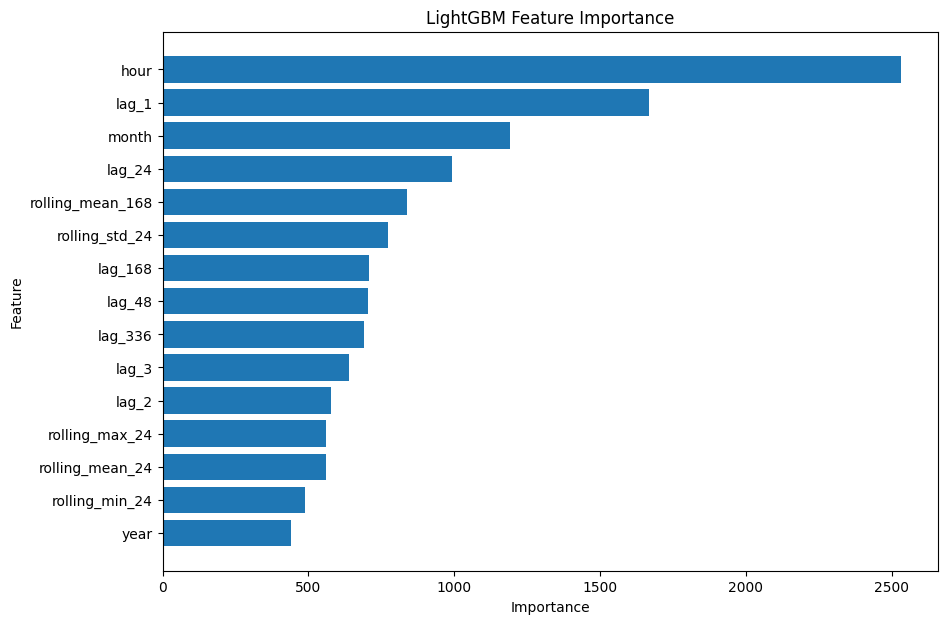

In [45]:
plt.figure(figsize=(10, 7))

top_features = feature_importance.head(15)

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.title("LightGBM Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [46]:
model_df[
    [
        "datetime",
        "demand_mw_clean",
        "lag_1",
        "lag_24",
        "lag_168",
        "rolling_mean_24"
    ]
].head(30)

,datetime,demand_mw_clean,lag_1,lag_24,lag_168,rolling_mean_24
0,2015-05-03 21:00:00,6770.0,6812.0,6415.0,6363.0,5807.208333
1,2015-05-03 22:00:00,6823.0,6770.0,6267.0,5995.0,5822.000000
2,2015-05-04 00:00:00,6062.0,6481.0,5669.0,5236.0,5868.750000
3,2015-05-04 07:00:00,5239.0,5065.0,4840.0,4800.0,5977.125000
4,2015-05-04 08:00:00,5692.0,5239.0,5321.0,5200.0,5993.750000
5,2015-05-04 09:00:00,5976.0,5692.0,5398.0,5430.0,6009.208333
6,2015-05-04 10:00:00,6101.0,5976.0,5555.0,5531.0,6033.291667
7,2015-05-04 11:00:00,6140.0,6101.0,5788.0,5602.0,6056.041667
8,2015-05-04 12:00:00,6461.0,6140.0,6144.0,5459.0,6070.708333
9,2015-05-04 13:00:00,6351.0,6461.0,5969.0,5424.0,6083.916667


In [47]:
results.to_csv(
    "../results/traditional_model_results.csv",
    index=False
)

print("Traditional-model benchmark saved.")

Traditional-model benchmark saved.
